## Magnetometer Noise Profiling

In [22]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

path = './imuLog00027.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 304 samples


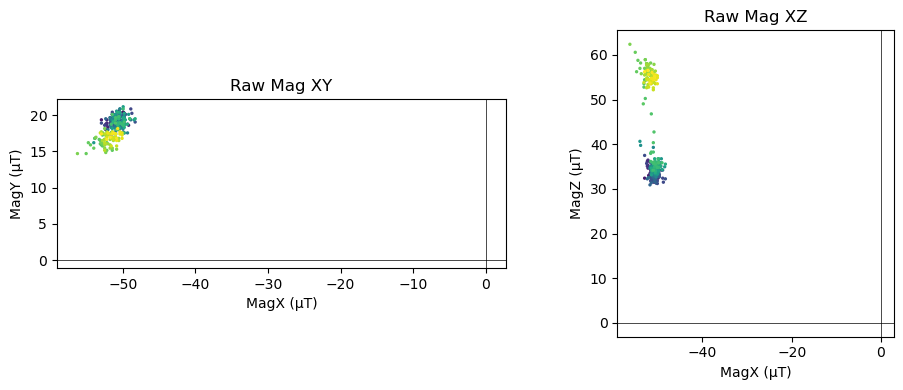

In [23]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

In [24]:
## Gyroscope & Accelerometer — extract channels

ax = [r['AccX'] for r in rows]   # mg
ay = [r['AccY'] for r in rows]
az = [r['AccZ'] for r in rows]

gx = [r['GyrX'] for r in rows]   # °/s
gy = [r['GyrY'] for r in rows]
gz = [r['GyrZ'] for r in rows]

acc_mag = np.sqrt(np.array(ax)**2 + np.array(ay)**2 + np.array(az)**2)

print(f'Acc magnitude  — mean: {acc_mag.mean():.1f} mg   std: {acc_mag.std():.2f} mg')
print(f'Gyro X         — mean: {np.mean(gx):.4f} °/s   std: {np.std(gx):.4f} °/s')
print(f'Gyro Y         — mean: {np.mean(gy):.4f} °/s   std: {np.std(gy):.4f} °/s')
print(f'Gyro Z         — mean: {np.mean(gz):.4f} °/s   std: {np.std(gz):.4f} °/s')

Acc magnitude  — mean: 1014.8 mg   std: 26.62 mg
Gyro X         — mean: 0.0463 °/s   std: 1.0350 °/s
Gyro Y         — mean: 0.1255 °/s   std: 1.7110 °/s
Gyro Z         — mean: -0.2152 °/s   std: 1.7606 °/s


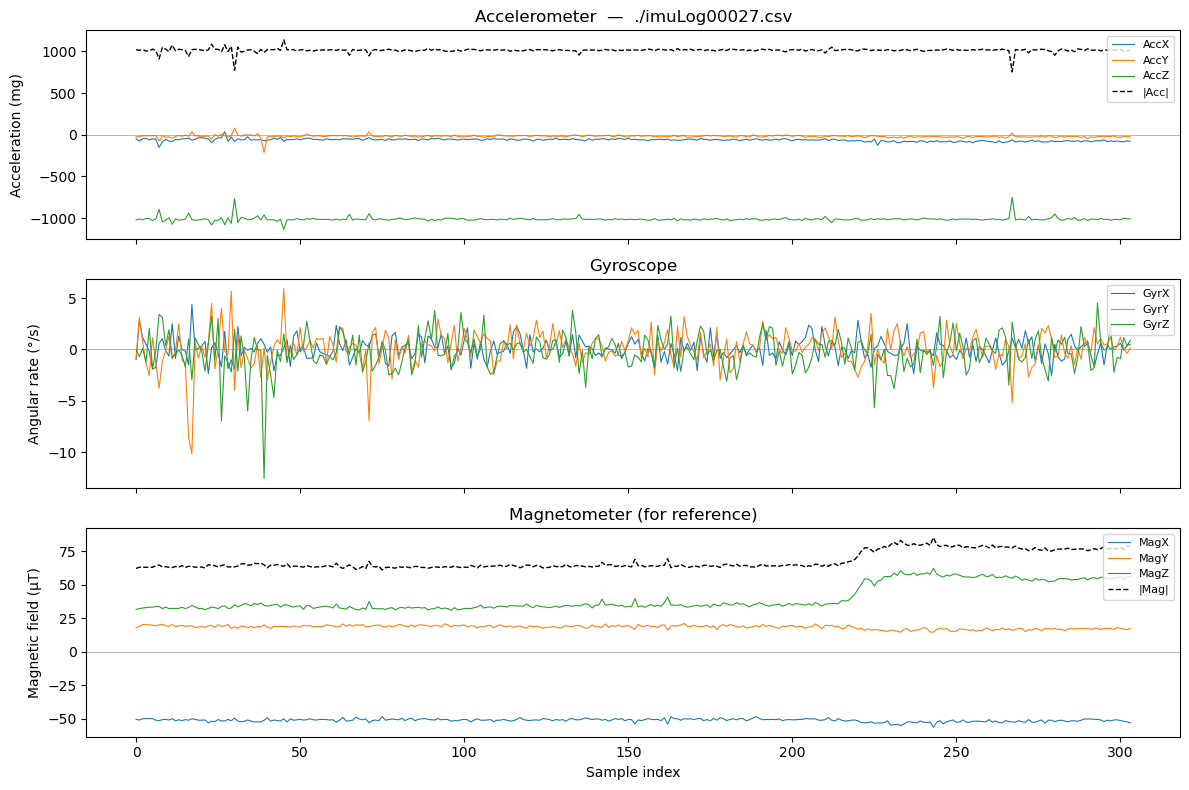

In [25]:
## Gyroscope & Accelerometer — time-series plots

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Accelerometer
axes[0].plot(t, ax, label='AccX', lw=0.8)
axes[0].plot(t, ay, label='AccY', lw=0.8)
axes[0].plot(t, az, label='AccZ', lw=0.8)
axes[0].plot(t, acc_mag, label='|Acc|', color='k', lw=1, ls='--')
axes[0].axhline(0, color='grey', lw=0.4)
axes[0].set_ylabel('Acceleration (mg)')
axes[0].set_title(f'Accelerometer  —  {path}')
axes[0].legend(loc='upper right', fontsize=8)

# Gyroscope
axes[1].plot(t, gx, label='GyrX', lw=0.8)
axes[1].plot(t, gy, label='GyrY', lw=0.8)
axes[1].plot(t, gz, label='GyrZ', lw=0.8)
axes[1].axhline(0, color='grey', lw=0.4)
axes[1].set_ylabel('Angular rate (°/s)')
axes[1].set_title('Gyroscope')
axes[1].legend(loc='upper right', fontsize=8)

# Magnetometer magnitude for reference
mag_mag = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)
axes[2].plot(t, mx, label='MagX', lw=0.8)
axes[2].plot(t, my, label='MagY', lw=0.8)
axes[2].plot(t, mz, label='MagZ', lw=0.8)
axes[2].plot(t, mag_mag, label='|Mag|', color='k', lw=1, ls='--')
axes[2].axhline(0, color='grey', lw=0.4)
axes[2].set_ylabel('Magnetic field (µT)')
axes[2].set_xlabel('Sample index')
axes[2].set_title('Magnetometer (for reference)')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Window: samples 77 – 97  (20 samples)


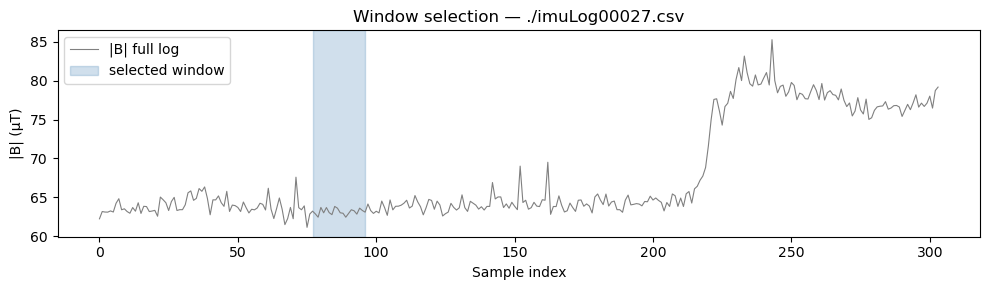

In [26]:
## Time window selection
# Override i_start / i_end manually, or leave as None to auto-detect the flattest window.
i_start = None
i_end   = None

win = 20   # sliding-window width used for auto-detection (samples)

B_all = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)

if i_start is None or i_end is None:
    stds = [B_all[i:i+win].std() for i in range(len(B_all) - win)]
    best = int(np.argmin(stds))
    i_start, i_end = best, best + win

print(f'Window: samples {i_start} – {i_end}  ({i_end - i_start} samples)')

fig, axes_w = plt.subplots(figsize=(10, 3))
axes_w.plot(t, B_all, lw=0.8, color='grey', label='|B| full log')
axes_w.axvspan(i_start, i_end - 1, alpha=0.25, color='steelblue', label='selected window')
axes_w.set_xlabel('Sample index'); axes_w.set_ylabel('|B| (µT)')
axes_w.set_title(f'Window selection — {path}')
axes_w.legend(); plt.tight_layout(); plt.show()

|B| raw  — mean: 63.14 µT   std: 0.389 µT
|B| cal  — mean: 24.15 µT   std: 0.710 µT


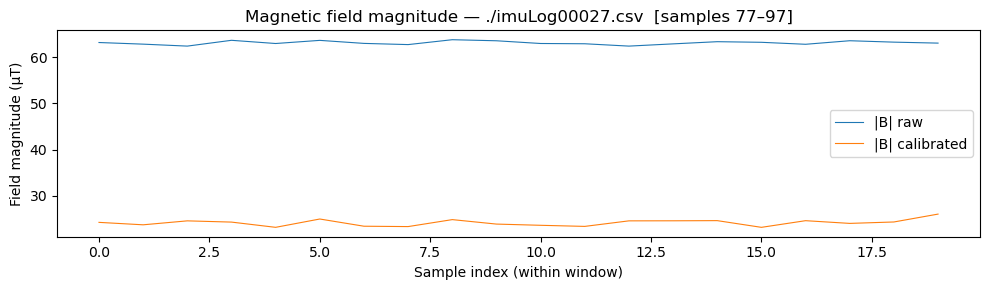

In [29]:
## Magnetic field magnitude

b = np.array([27.975,-20.700,-41.250 ])

# Windowed slices
mx_w = np.array(mx)[i_start:i_end];  my_w = np.array(my)[i_start:i_end];  mz_w = np.array(mz)[i_start:i_end]
mx_c = mx_w + b[0];  my_c = my_w + b[1];  mz_c = mz_w + b[2]
t_w  = list(range(i_end - i_start))

B_raw = np.sqrt(mx_w**2 + my_w**2 + mz_w**2)
B_cal = np.sqrt(mx_c**2 + my_c**2 + mz_c**2)

print(f'|B| raw  — mean: {B_raw.mean():.2f} µT   std: {B_raw.std():.3f} µT')
print(f'|B| cal  — mean: {B_cal.mean():.2f} µT   std: {B_cal.std():.3f} µT')

fig, ax_b = plt.subplots(figsize=(10, 3))
ax_b.plot(t_w, B_raw, label='|B| raw',        lw=0.8)
ax_b.plot(t_w, B_cal, label='|B| calibrated', lw=0.8)
ax_b.set_xlabel('Sample index (within window)')
ax_b.set_ylabel('Field magnitude (µT)')
ax_b.set_title(f'Magnetic field magnitude — {path}  [samples {i_start}–{i_end}]')
ax_b.legend(); plt.tight_layout(); plt.show()

Heading raw  — mean: 158.8°   std: 0.76°
Heading cal  — mean: 152.8°   std: 0.48°


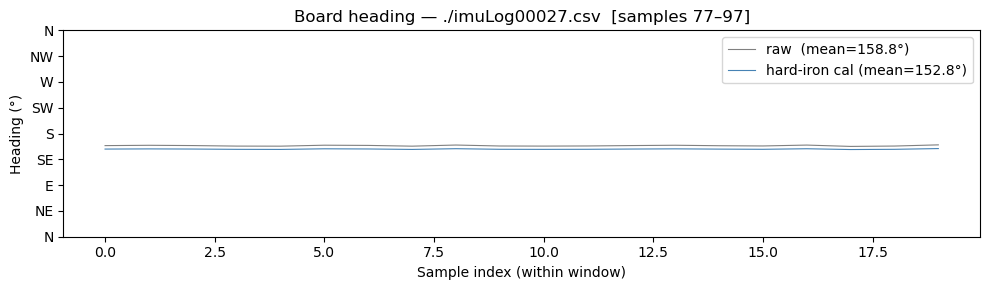

In [28]:
## Board heading from atan2(MagY, MagX)
# Assumes board is flat (no tilt compensation). Uses windowed data from above.

heading_raw = np.degrees(np.arctan2(my_w, mx_w)) % 360
heading_cal = np.degrees(np.arctan2(my_c, mx_c)) % 360

print(f'Heading raw  — mean: {heading_raw.mean():.1f}°   std: {heading_raw.std():.2f}°')
print(f'Heading cal  — mean: {heading_cal.mean():.1f}°   std: {heading_cal.std():.2f}°')

fig, ax_h = plt.subplots(figsize=(10, 3))
ax_h.plot(t_w, heading_raw, lw=0.8, color='grey',      label=f'raw  (mean={heading_raw.mean():.1f}°)')
ax_h.plot(t_w, heading_cal, lw=0.8, color='steelblue', label=f'hard-iron cal (mean={heading_cal.mean():.1f}°)')
ax_h.set_xlabel('Sample index (within window)')
ax_h.set_ylabel('Heading (°)')
ax_h.set_title(f'Board heading — {path}  [samples {i_start}–{i_end}]')
ax_h.set_ylim(0, 360)
ax_h.set_yticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax_h.set_yticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
ax_h.legend(); plt.tight_layout(); plt.show()